# Gradient Boosting Regression — Retail Sales Forecasting

This notebook builds a **Gradient Boosting Regression** model to forecast hourly retail sales.  
It uses the same data pipeline (hourly aggregation, 95th-percentile capping, 168-hour holdout) as the Random Forest and XGBoost models for a fair comparison.

---

## 1 · Imports & Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Scikit-learn
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Persistence
import joblib, os

print('All imports loaded successfully')

All imports loaded successfully ✓


---
## 2 · Data Loading

In [2]:
DATA_PATH = os.path.join('..', '..', 'Forecasting', 'cleaned_online_retail.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate'])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')
df.head()

Dataset shape : (397924, 8)
Date range    : 2010-12-01 08:26:00 → 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
## 3 · Feature Engineering

### 3.1 — TotalSales & Hourly Aggregation

In [3]:
# Revenue per line item
df['TotalSales'] = df['UnitPrice'] * df['Quantity']

# Resample to hourly frequency
hourly_df = (
    df
    .set_index('InvoiceDate')['TotalSales']
    .resample('h')
    .sum()
    .reset_index()
)

# Cap extreme values at the 95th percentile
cap = hourly_df['TotalSales'].quantile(0.95)
hourly_df['CappedSales'] = np.where(
    hourly_df['TotalSales'] > cap, cap, hourly_df['TotalSales']
)

print(f'Hourly records : {len(hourly_df)}')
print(f'95th-pctl cap  : £{cap:,.2f}')
hourly_df.head()

Hourly records : 8957
95th-pctl cap  : £4,991.07


,InvoiceDate,TotalSales,CappedSales
0,2010-12-01 08:00:00,1383.81,1383.810
1,2010-12-01 09:00:00,7356.39,4991.066
2,2010-12-01 10:00:00,5235.81,4991.066
3,2010-12-01 11:00:00,4234.16,4234.160
4,2010-12-01 12:00:00,7447.92,4991.066


### 3.2 — Prepare ML DataFrame & Engineer Features

In [5]:
ml_df = hourly_df[['InvoiceDate', 'CappedSales']].copy()
ml_df.columns = ['ds', 'y']
ml_df.set_index('ds', inplace=True)

# Calendar features
ml_df['hour']         = ml_df.index.hour
ml_df['day_of_week']  = ml_df.index.dayofweek
ml_df['day_of_month'] = ml_df.index.day
ml_df['month']        = ml_df.index.month
ml_df['week_of_year'] = ml_df.index.isocalendar().week.astype(int)
ml_df['quarter']      = ml_df.index.quarter
ml_df['is_weekend']   = (ml_df.index.dayofweek >= 5).astype(int)

# Interaction
ml_df['hour_weekend'] = ml_df['hour'] * ml_df['is_weekend']

# Lag features
ml_df['lag_1']   = ml_df['y'].shift(1)
ml_df['lag_24']  = ml_df['y'].shift(24)
ml_df['lag_168'] = ml_df['y'].shift(168)

# Rolling features
ml_df['rolling_mean_24']  = ml_df['y'].shift(1).rolling(window=24).mean()
ml_df['rolling_std_24']   = ml_df['y'].shift(1).rolling(window=24).std()
ml_df['rolling_mean_168'] = ml_df['y'].shift(1).rolling(window=168).mean()

# Drop NaN rows
rows_before = len(ml_df)
ml_df.dropna(inplace=True)
print(f'Rows dropped: {rows_before - len(ml_df)}')
print(f'Final shape : {ml_df.shape}  ({ml_df.shape[1]-1} features)')
ml_df.head()

Rows dropped: 168
Final shape : (8789, 15)  (14 features)


,y,hour,day_of_week,day_of_month,month,week_of_year,quarter,is_weekend,hour_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
ds,,,,,,,,,,,,,,,
2010-12-08 08:00:00,539.450,8,2,8,12,49,4,0,0,0.000,0.00,1383.810,1296.585917,1963.782570,1110.820464
2010-12-08 09:00:00,2628.540,9,2,8,12,49,4,0,0,539.450,4865.96,4991.066,1319.063000,1951.344688,1105.794512
2010-12-08 10:00:00,4991.066,10,2,8,12,49,4,0,0,2628.540,3880.05,4991.066,1225.837167,1823.801887,1091.731857
2010-12-08 11:00:00,1997.950,11,2,8,12,49,4,0,0,4991.066,4595.98,4234.160,1272.129500,1906.333806,1091.731857
2010-12-08 12:00:00,4991.066,12,2,8,12,49,4,0,0,1997.950,2434.69,4991.066,1163.878250,1778.886933,1078.421083


---
## 4 · Train / Test Split

Last **168 hours (1 week)** held out — identical to RF and XGBoost.

In [6]:
HOLDOUT_HOURS = 168

train = ml_df.iloc[:-HOLDOUT_HOURS]
test  = ml_df.iloc[-HOLDOUT_HOURS:]

feature_cols = [c for c in ml_df.columns if c != 'y']

X_train, y_train = train[feature_cols], train['y']
X_test,  y_test  = test[feature_cols],  test['y']

print(f'Training : {X_train.shape[0]:,} samples  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test     : {X_test.shape[0]:,} samples  ({test.index.min().date()} → {test.index.max().date()})')
print(f'Features : {X_train.shape[1]}')

Training : 8,621 samples  (2010-12-08 → 2011-12-02)
Test     : 168 samples  (2011-12-02 → 2011-12-09)
Features : 14


---
## 5 · Baseline Gradient Boosting Model

In [7]:
gb_baseline = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_baseline.fit(X_train, y_train)
y_pred_base = gb_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print('Baseline Gradient Boosting')
print(f'  MAE  : £{mae_base:,.2f}')
print(f'  RMSE : £{rmse_base:,.2f}')
print(f'  R²   : {r2_base:.4f}')

Baseline Gradient Boosting
  MAE  : £439.54
  RMSE : £838.85
  R²   : 0.7959


---
## 6 · Hyperparameter Tuning (RandomizedSearchCV)

In [8]:
param_distributions = {
    'n_estimators'     : [200, 300, 500, 700, 1000],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth'        : [3, 4, 5, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print('Starting hyperparameter search (30 iterations × 5 folds = 150 fits)...')
gb_search.fit(X_train, y_train)

print(f'\nBest CV MAE: £{-gb_search.best_score_:,.2f}')
print(f'\nBest parameters:')
for k, v in gb_search.best_params_.items():
    print(f'  {k:>20s} : {v}')

Starting hyperparameter search (30 iterations × 5 folds = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Best CV MAE: £407.09

Best parameters:
             subsample : 0.8
          n_estimators : 500
     min_samples_split : 10
      min_samples_leaf : 1
          max_features : sqrt
             max_depth : 4
         learning_rate : 0.01


---
## 7 · Final Model Selection

In [9]:
gb_tuned = gb_search.best_estimator_

y_pred_tuned = gb_tuned.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

print('Tuned Gradient Boosting')
print(f'  MAE  : £{mae_tuned:,.2f}')
print(f'  RMSE : £{rmse_tuned:,.2f}')
print(f'  R²   : {r2_tuned:.4f}')

# Select the best model (lower MAE wins)
if mae_base <= mae_tuned:
    gb_best = gb_baseline
    y_pred_best = y_pred_base
    best_label = 'Baseline'
    print('\nBaseline GB selected as final model (lower MAE)')
else:
    gb_best = gb_tuned
    y_pred_best = y_pred_tuned
    best_label = 'Tuned'
    print('\nTuned GB selected as final model (lower MAE)')

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print(f'\nFinal Model ({best_label})')
print(f'  MAE  : £{mae_best:,.2f}')
print(f'  RMSE : £{rmse_best:,.2f}')
print(f'  R²   : {r2_best:.4f}')

Tuned Gradient Boosting
  MAE  : £416.82
  RMSE : £799.85
  R²   : 0.8145

Tuned GB selected as final model (lower MAE)

Final Model (Tuned)
  MAE  : £416.82
  RMSE : £799.85
  R²   : 0.8145


---
## 8 · Evaluation & Comparison

### 8.1 — Baseline vs Tuned

In [10]:
improvement = pd.DataFrame({
    'Metric': ['MAE (£)', 'RMSE (£)', 'R²'],
    'Baseline GB': [round(mae_base, 2), round(rmse_base, 2), round(r2_base, 4)],
    'Tuned GB':    [round(mae_tuned, 2), round(rmse_tuned, 2), round(r2_tuned, 4)],
    'Change':      [
        f'{((mae_tuned - mae_base)/mae_base)*100:+.2f}%',
        f'{((rmse_tuned - rmse_base)/rmse_base)*100:+.2f}%',
        f'{(r2_tuned - r2_base):+.4f}'
    ]
})
print('\nBaseline vs Tuned GB')
print(improvement.to_string(index=False))


Baseline vs Tuned GB
  Metric  Baseline GB  Tuned GB  Change
 MAE (£)     439.5400  416.8200  -5.17%
RMSE (£)     838.8500  799.8500  -4.65%
      R²       0.7959    0.8145 +0.0185


### 8.2 — Cross-Model Comparison

Load the Random Forest model for side-by-side comparison.

In [15]:
comparison_data = {
    'Model':    ['Gradient Boosting (Baseline)', 'Gradient Boosting (Tuned)'],
    'MAE (£)':  [round(mae_base, 2), round(mae_tuned, 2)],
    'RMSE (£)': [round(rmse_base, 2), round(rmse_tuned, 2)],
    'R²':       [round(r2_base, 4), round(r2_tuned, 4)],
}

# Load RF model if available
rf_model_path = 'rf_sales_model.pkl'
if os.path.exists(rf_model_path):
    try:
        rf_model = joblib.load(rf_model_path)
        y_pred_rf = rf_model.predict(X_test)
        comparison_data['Model'].append('Random Forest (Best)')
        comparison_data['MAE (£)'].append(round(mean_absolute_error(y_test, y_pred_rf), 2))
        comparison_data['RMSE (£)'].append(round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2))
        comparison_data['R²'].append(round(r2_score(y_test, y_pred_rf), 4))
        print('Random Forest model loaded')
    except Exception as e:
        print(f'Could not load RF model: {e}')
else:
    print('RF model not found — run random_forest_regression.ipynb first')

# Load XGBoost model if available
xgb_model_path = os.path.join('..', 'Forecasting', 'xgb_sales_forecast_model.pkl')
if os.path.exists(xgb_model_path):
    try:
        import xgboost as xgb
        model_xgb = joblib.load(xgb_model_path)
        X_test_xgb = X_test[['hour', 'day_of_week', 'month', 'is_weekend',
                              'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']].copy()
        X_test_xgb.rename(columns={'day_of_week': 'dayofweek'}, inplace=True)
        y_pred_xgb = model_xgb.predict(X_test_xgb)
        comparison_data['Model'].append('XGBoost (Friend\'s Model)')
        comparison_data['MAE (£)'].append(round(mean_absolute_error(y_test, y_pred_xgb), 2))
        comparison_data['RMSE (£)'].append(round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 2))
        comparison_data['R²'].append(round(r2_score(y_test, y_pred_xgb), 4))
        print('XGBoost model loaded')
    except Exception as e:
        print(f'Could not load XGBoost model: {e}')

comparison_df = pd.DataFrame(comparison_data)
print('\nModel Comparison (168-hour holdout)')
print(comparison_df.to_string(index=False))

RF model not found — run random_forest_regression.ipynb first

Model Comparison (168-hour holdout)
                       Model  MAE (£)  RMSE (£)     R²
Gradient Boosting (Baseline)   439.54    838.85 0.7959
   Gradient Boosting (Tuned)   416.82    799.85 0.8145


---
## 9 · Visualizations

### 9.1 — Actual vs Predicted

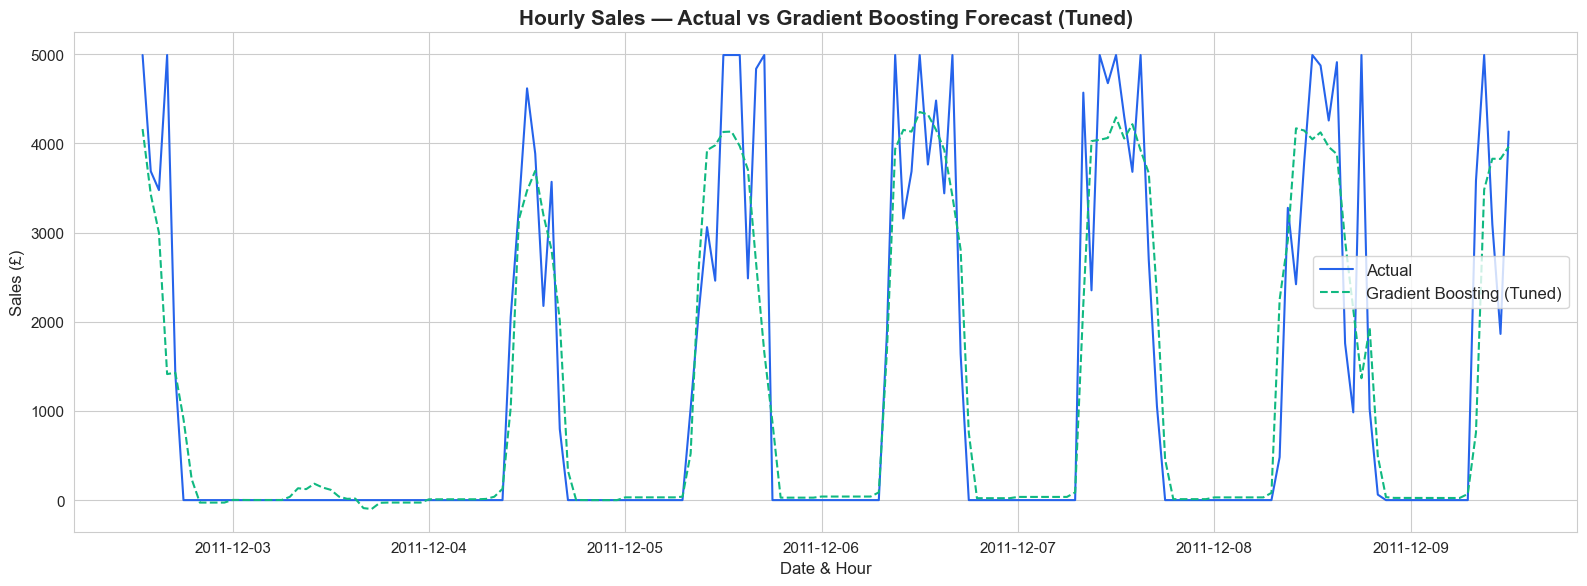

Plot saved → gb_actual_vs_predicted.png


In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test.index, y_test, label='Actual', color='#2563EB', linewidth=1.5)
ax.plot(test.index, y_pred_best, label=f'Gradient Boosting ({best_label})', color='#10B981',
        linewidth=1.5, linestyle='--')
ax.set_title(f'Hourly Sales — Actual vs Gradient Boosting Forecast ({best_label})',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date & Hour')
ax.set_ylabel('Sales (£)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('gb_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → gb_actual_vs_predicted.png')

### 9.2 — Residual Analysis

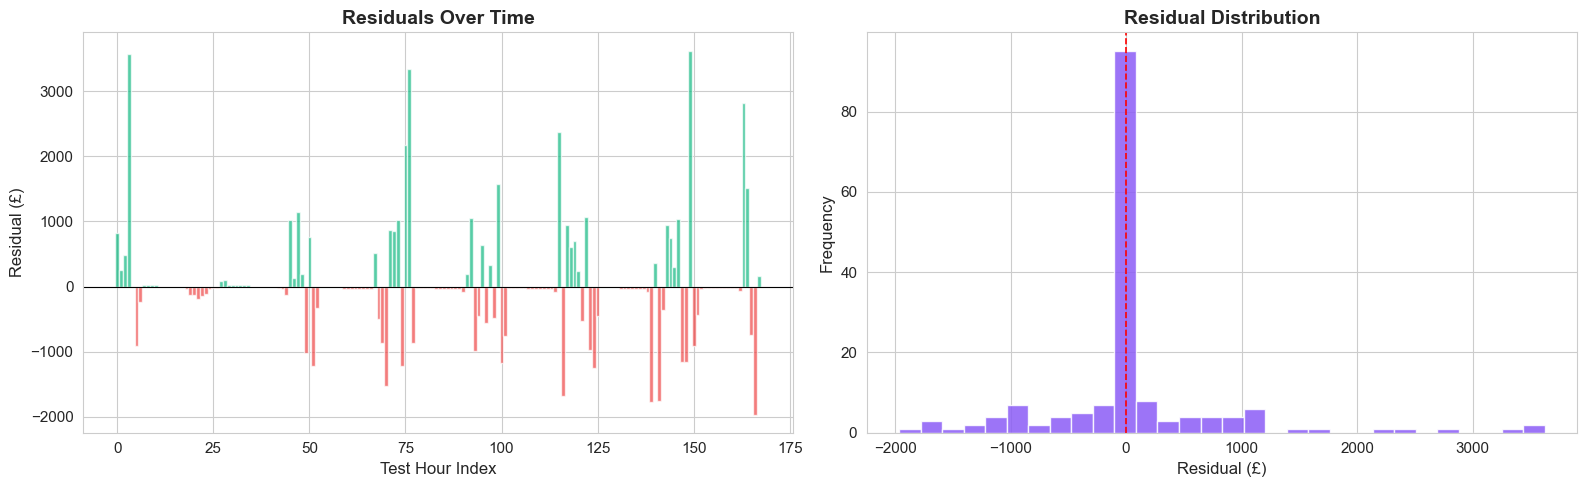

Plot saved → gb_residual_analysis.png


In [17]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(residuals)), residuals,
            color=np.where(residuals >= 0, '#10B981', '#EF4444'), alpha=0.7, width=1.0)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals Over Time', fontweight='bold')
axes[0].set_xlabel('Test Hour Index')
axes[0].set_ylabel('Residual (£)')

axes[1].hist(residuals, bins=30, color='#8B5CF6', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (£)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('gb_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → gb_residual_analysis.png')

### 9.3 — Feature Importance

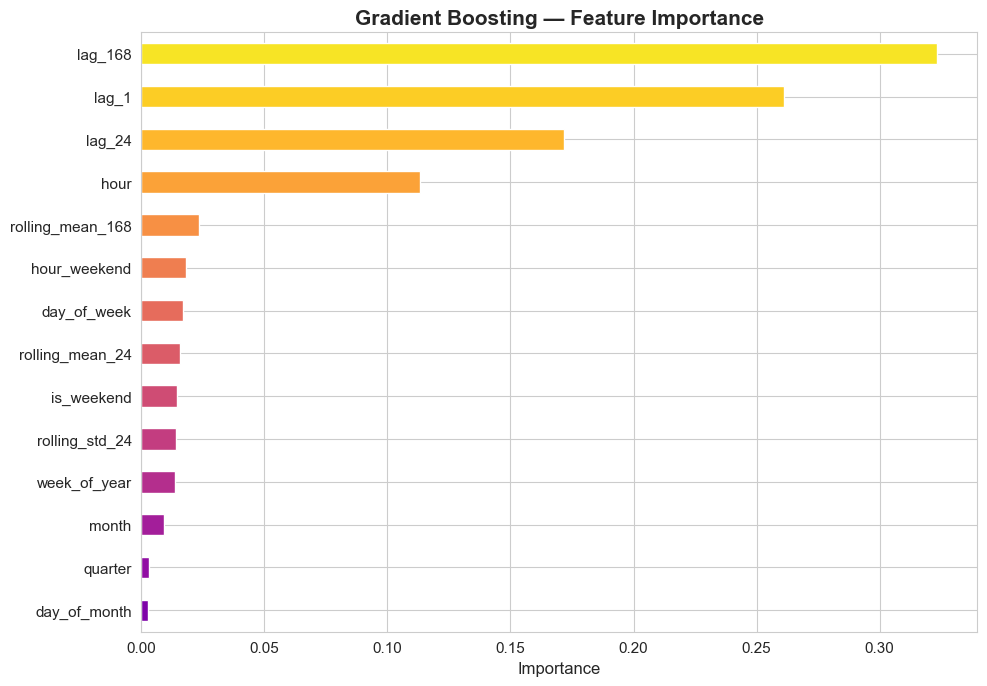

Plot saved → gb_feature_importance.png


In [18]:
importances = pd.Series(gb_best.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0.25, 0.95, len(importances)))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Gradient Boosting — Feature Importance', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → gb_feature_importance.png')

### 9.4 — Actual vs Predicted Scatter Plot

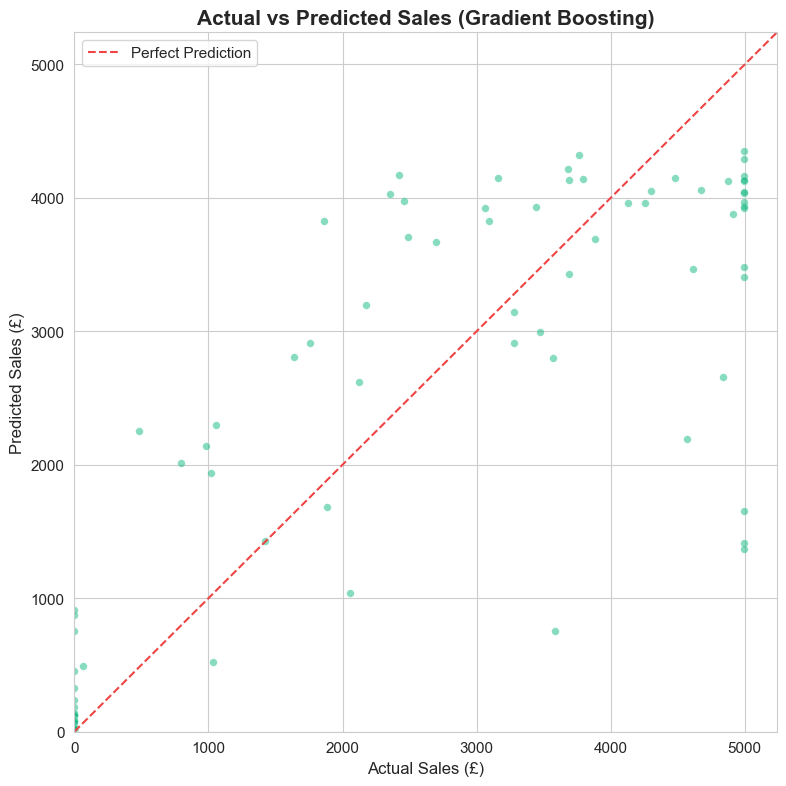

Plot saved → gb_scatter_actual_vs_predicted.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.5, s=30, color='#10B981', edgecolors='white', linewidth=0.3)

lims = [0, max(y_test.max(), y_pred_best.max()) * 1.05]
ax.plot(lims, lims, '--', color='#EF4444', linewidth=1.5, label='Perfect Prediction')

ax.set_title('Actual vs Predicted Sales (Gradient Boosting)', fontsize=15, fontweight='bold')
ax.set_xlabel('Actual Sales (£)')
ax.set_ylabel('Predicted Sales (£)')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.savefig('gb_scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → gb_scatter_actual_vs_predicted.png')

---
## 10 · Model Persistence

In [20]:
MODEL_PATH = 'gb_sales_model.pkl'
joblib.dump(gb_best, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}  (variant: {best_label})')
print(f'File size   : {os.path.getsize(MODEL_PATH) / 1024**2:.1f} MB')

Model saved → gb_sales_model.pkl  (variant: Tuned)
File size   : 1.1 MB


### Sanity check — reload & predict

In [21]:
gb_loaded = joblib.load(MODEL_PATH)
y_check   = gb_loaded.predict(X_test)
assert np.allclose(y_check, y_pred_best), 'Mismatch after reload!'
print('Reload sanity check passed')

Reload sanity check passed
